# Reasoning Under Compression: Core Findings

This is the final showcase notebook for the project. It distills the workflow and empirical findings developed across the notebooks:

| Notebook | Role |
|---|---|
| `01_data_loading_engineering.ipynb` | Local feature loading, grouped split, train-only target thresholds |
| `02_prompt_level_compressibility.ipynb` | Prompt-level prediction before any reasoning block is observed |
| `03_block_level_compressibility.ipynb` | Online current-block prediction without full-trace retrospective features |
| `04_sequential_compressibility.ipynb` | Online current-block prediction with prior within-trace history |

This notebook presents the fundamental process and the resulting findings from those modeling notebooks.

## Executive Thesis

The central finding is that reasoning-trace compressibility is predictable, but not mainly from the prompt alone.

- Prompt-level features contain modest signal about whole-trace compressibility.
- Once the current reasoning block is observed, block-summary compressibility becomes much more predictable.
- Prior within-trace compression history adds some signal, but the current block remains the dominant source of predictive information.
- This supports the project framing: compressibility is partly an emergent property of the generated reasoning trajectory, not only a static property of the original problem.

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings("ignore", message="IProgress not found.*")

sys.path.append(str(Path("..").resolve()))

from src.reasoning_compression.features import (
    count_share_table,
    format_describe,
    latest_feature_build_dir,
    normalize_difficulty,
)

plt.style.use("seaborn-v0_8-whitegrid")

# 1. Data Products

The analysis uses two local labeled parquet tables produced by `01_data_loading_engineering.ipynb`:

- one trace-level table, with one row per original problem-response trace;
- one block-level table, with one row per aligned reasoning block and memento summary.

Both tables contain a persisted grouped train/test split, assigned at the trace level and copied to block rows.

In [2]:
FULL_BUILD_DIR = latest_feature_build_dir(Path("../data/full_feature_builds"))

df_traces = pd.read_parquet(
    FULL_BUILD_DIR / "traces_features_full_labeled.parquet"
)
df_blocks = pd.read_parquet(
    FULL_BUILD_DIR / "blocks_features_full_labeled.parquet"
)

df_traces["difficulty"] = df_traces["difficulty"].map(normalize_difficulty)
df_blocks["difficulty"] = df_blocks["difficulty"].map(normalize_difficulty)

dataset_summary = pd.DataFrame([
    {
        "table": "trace-level",
        "unit": "one original reasoning trace",
        "rows": len(df_traces),
        "columns": len(df_traces.columns),
    },
    {
        "table": "block-level",
        "unit": "one reasoning block-summary pair",
        "rows": len(df_blocks),
        "columns": len(df_blocks.columns),
    },
])

dataset_summary

,table,unit,rows,columns
0,trace-level,one original reasoning trace,228557,27
1,block-level,one reasoning block-summary pair,2013510,23


In [3]:
domain_coverage = count_share_table(df_traces, "domain")
domain_coverage

,n_rows,share_pct
domain,,
math,123333,53.96
science,61485,26.90
code,43739,19.14


The data are large enough to support held-out evaluation at both levels. The domain mix is dominated by math, followed by science and code, so domain metadata is retained as a predictor but not treated as the central signal.

# 2. Compression Target and Split

Compression is measured as the ratio of summary tokens to original block tokens. Lower ratios mean stronger compression. The binary target marks the most compressed quartile:

`high_token_compression = 1` when a block's summary-to-block token ratio is at or below the 25th percentile computed on the training split.

The trace-level target is defined analogously from total trace summary tokens divided by total trace block tokens.

In [4]:
block_target_balance = (
    df_blocks
    .groupby("model_split")["high_token_compression"]
    .value_counts(normalize=True)
    .rename("share")
    .reset_index()
    .assign(level="block", share_pct=lambda df: (df["share"] * 100).round(2))
    .rename(columns={"high_token_compression": "target_value"})
    .drop(columns="share")
)

trace_target_balance = (
    df_traces
    .groupby("model_split")["trace_high_token_compression"]
    .value_counts(normalize=True)
    .rename("share")
    .reset_index()
    .assign(level="trace", share_pct=lambda df: (df["share"] * 100).round(2))
    .rename(columns={"trace_high_token_compression": "target_value"})
    .drop(columns="share")
)

target_balance = pd.concat(
    [block_target_balance, trace_target_balance],
    ignore_index=True,
)[["level", "model_split", "target_value", "share_pct"]]

target_balance

,level,model_split,target_value,share_pct
0,block,test,0,75.03
1,block,test,1,24.97
2,block,train,0,75.00
3,block,train,1,25.00
4,trace,test,0,75.12
5,trace,test,1,24.88
6,trace,train,0,75.00
7,trace,train,1,25.00


The training split is anchored at 25% positives by construction. The test split remains close to that balance without being used to estimate the target threshold.

**Fixed-split limitation.** The project uses one persisted grouped train/test split. This keeps target construction leakage-free and makes notebooks 02-04 directly comparable. The tradeoff is that metrics are fixed-split estimates, not confidence intervals over repeated grouped splits. A future robustness notebook could recompute fold-specific thresholds under repeated grouped splits.

# 3. Compression Behavior Along Reasoning

Before modeling, the descriptive question is whether compression changes over the generated reasoning trajectory. If compression were purely prompt-determined, block position and within-trace history would add little value. If compression evolves, sequential modeling becomes substantively meaningful.

In [5]:
compression_summary = pd.DataFrame({
    "block_summary_to_block_token_ratio": format_describe(
        df_blocks["summary_to_block_token_ratio"].describe()
    ),
    "trace_summary_to_block_token_ratio": format_describe(
        df_traces["trace_total_summary_to_block_token_ratio"].describe()
    ),
})

compression_summary

,block_summary_to_block_token_ratio,trace_summary_to_block_token_ratio
count,"2,013,510","228,557"
mean,0.2154,0.1847
std,0.1476,0.0772
min,0.0005,0.0119
25%,0.1089,0.1328
50%,0.1778,0.1692
75%,0.2817,0.2178
max,2.7774,0.8113


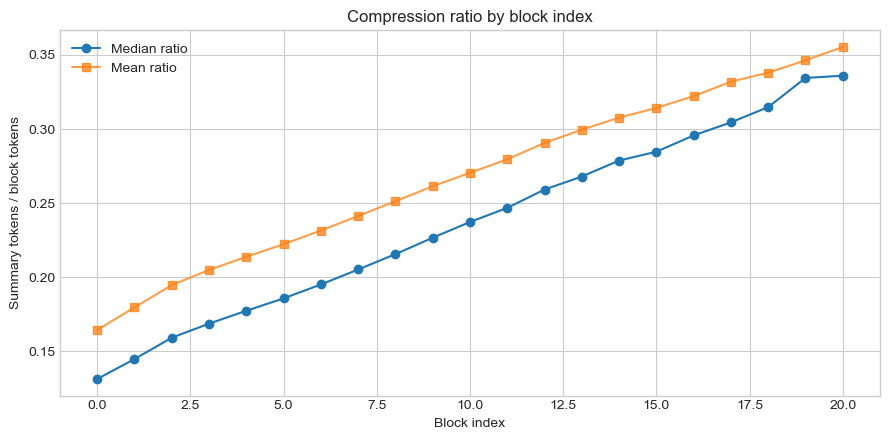

In [6]:
compression_by_block_index = (
    df_blocks
    .groupby("block_index")
    .agg(
        n_blocks=("summary_to_block_token_ratio", "size"),
        mean_ratio=("summary_to_block_token_ratio", "mean"),
        median_ratio=("summary_to_block_token_ratio", "median"),
    )
    .reset_index()
    .query("block_index <= 20")
)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(
    compression_by_block_index["block_index"],
    compression_by_block_index["median_ratio"],
    marker="o",
    label="Median ratio",
)
ax.plot(
    compression_by_block_index["block_index"],
    compression_by_block_index["mean_ratio"],
    marker="s",
    label="Mean ratio",
    alpha=0.75,
)
ax.set_title("Compression ratio by block index")
ax.set_xlabel("Block index")
ax.set_ylabel("Summary tokens / block tokens")
ax.legend()
fig.tight_layout()

Compression is not flat over the reasoning trajectory. The post-hoc trajectory view motivates the sequential notebook, while the online modeling notebooks avoid using future-known full-trace features such as final trace length or relative position.

# 4. Predictive Designs

The main analysis compares three information sets.

| Design | Prediction moment | Information used | Source notebook |
|---|---|---|---|
| Prompt-level | before reasoning starts | problem features + metadata | `02_prompt_level_compressibility.ipynb` |
| Block-level | after current block is observed | problem + metadata + current block | `03_block_level_compressibility.ipynb` |
| Sequential | after current block, with prior history | problem + metadata + current block + prior compression history | `04_sequential_compressibility.ipynb` |

The block-level and sequential notebooks intentionally exclude `n_blocks_in_trace` and `relative_block_position` from model features because those require knowing the full future trace.

In [7]:
model_results = pd.DataFrame([
    {
        "task": "Prompt-level",
        "information_set": "problem + metadata",
        "model": "Dummy",
        "accuracy": 0.7512,
        "balanced_accuracy": 0.5000,
        "roc_auc": 0.5000,
        "source": "02_prompt_level_compressibility.ipynb",
    },
    {
        "task": "Prompt-level",
        "information_set": "problem + metadata",
        "model": "Random forest",
        "accuracy": 0.6294,
        "balanced_accuracy": 0.6247,
        "roc_auc": 0.6807,
        "source": "02_prompt_level_compressibility.ipynb",
    },
    {
        "task": "Prompt-level",
        "information_set": "problem + metadata",
        "model": "Gradient boosting",
        "accuracy": 0.5312,
        "balanced_accuracy": 0.6069,
        "roc_auc": 0.6444,
        "source": "02_prompt_level_compressibility.ipynb",
    },
    {
        "task": "Block-level",
        "information_set": "problem + current block + metadata",
        "model": "Dummy",
        "accuracy": 0.7503,
        "balanced_accuracy": 0.5000,
        "roc_auc": 0.5000,
        "source": "03_block_level_compressibility.ipynb",
    },
    {
        "task": "Block-level",
        "information_set": "problem + current block + metadata",
        "model": "Random forest",
        "accuracy": 0.7403,
        "balanced_accuracy": 0.7208,
        "roc_auc": 0.8053,
        "source": "03_block_level_compressibility.ipynb",
    },
    {
        "task": "Block-level",
        "information_set": "problem + current block + metadata",
        "model": "Gradient boosting",
        "accuracy": 0.7950,
        "balanced_accuracy": 0.6509,
        "roc_auc": 0.8076,
        "source": "03_block_level_compressibility.ipynb",
    },
    {
        "task": "Sequential",
        "information_set": "problem + current block + prior history + metadata",
        "model": "Dummy",
        "accuracy": 0.7503,
        "balanced_accuracy": 0.5000,
        "roc_auc": 0.5000,
        "source": "04_sequential_compressibility.ipynb",
    },
    {
        "task": "Sequential",
        "information_set": "problem + current block + prior history + metadata",
        "model": "Random forest",
        "accuracy": 0.7541,
        "balanced_accuracy": 0.7243,
        "roc_auc": 0.8114,
        "source": "04_sequential_compressibility.ipynb",
    },
    {
        "task": "Sequential",
        "information_set": "problem + current block + prior history + metadata",
        "model": "Gradient boosting",
        "accuracy": 0.7234,
        "balanced_accuracy": 0.7313,
        "roc_auc": 0.8130,
        "source": "04_sequential_compressibility.ipynb",
    },
])

model_results_display = model_results.copy()
for metric in ["accuracy", "balanced_accuracy", "roc_auc"]:
    model_results_display[metric] = (model_results_display[metric] * 100).round(2)

model_results_display

,task,information_set,model,accuracy,balanced_accuracy,roc_auc,source
0,Prompt-level,problem + metadata,Dummy,75.12,50.00,50.00,02_prompt_level_compressibility.ipynb
1,Prompt-level,problem + metadata,Random forest,62.94,62.47,68.07,02_prompt_level_compressibility.ipynb
2,Prompt-level,problem + metadata,Gradient boosting,53.12,60.69,64.44,02_prompt_level_compressibility.ipynb
3,Block-level,problem + current block + metadata,Dummy,75.03,50.00,50.00,03_block_level_compressibility.ipynb
4,Block-level,problem + current block + metadata,Random forest,74.03,72.08,80.53,03_block_level_compressibility.ipynb
5,Block-level,problem + current block + metadata,Gradient boosting,79.50,65.09,80.76,03_block_level_compressibility.ipynb
6,Sequential,problem + current block + prior history + meta...,Dummy,75.03,50.00,50.00,04_sequential_compressibility.ipynb
7,Sequential,problem + current block + prior history + meta...,Random forest,75.41,72.43,81.14,04_sequential_compressibility.ipynb
8,Sequential,problem + current block + prior history + meta...,Gradient boosting,72.34,73.13,81.30,04_sequential_compressibility.ipynb


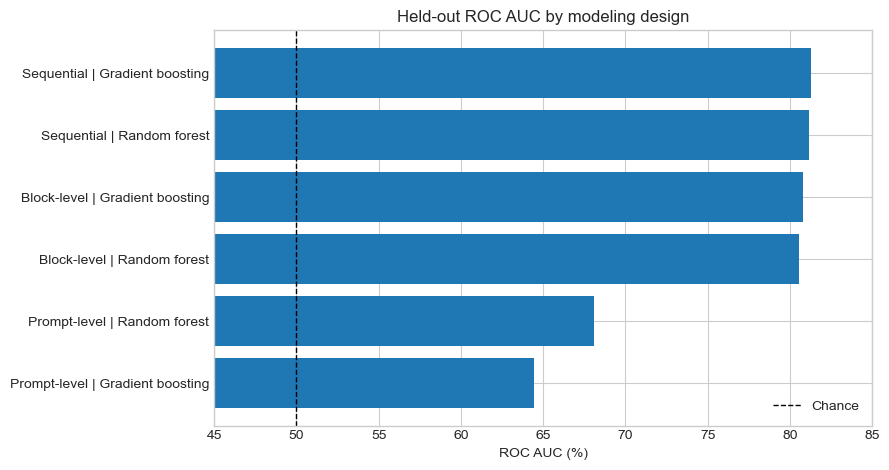

In [8]:
plot_df = model_results.query("model != 'Dummy'").copy()
plot_df["label"] = plot_df["task"] + " | " + plot_df["model"]
plot_df = plot_df.sort_values("roc_auc")

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.barh(plot_df["label"], plot_df["roc_auc"] * 100)
ax.axvline(50, color="black", linewidth=1, linestyle="--", label="Chance")
ax.set_title("Held-out ROC AUC by modeling design")
ax.set_xlabel("ROC AUC (%)")
ax.set_xlim(45, 85)
ax.legend(loc="lower right")
fig.tight_layout()

The modeling hierarchy is clear.

Prompt-only prediction is meaningfully above chance, but still weak. The best prompt-level ROC AUC is about 68%, so the problem statement contains some information about trace compressibility but does not determine it.

Current-block prediction is much stronger. Once the generated reasoning block is available, ROC AUC rises to about 81%. This is the central empirical result: block-summary compressibility is predictable from the observed reasoning block.

Sequential prediction is the strongest setting in this run, but only modestly stronger than current-block prediction. This means prior history matters, but it does not replace the dominant local signal carried by the current block.

# 5. What the Models Use

Feature diagnostics from notebooks 02-04 point to a consistent story: size and structure of the observed reasoning text dominate the signal. Prompt-level features help before reasoning is observed, but current-block features carry most of the predictive power once available.

In [9]:
feature_signal = pd.DataFrame([
    {
        "design": "Prompt-level RF",
        "top signals": "problem_chars, problem_math_symbol_share, problem_tokens",
        "interpretation": "Prompt surface form gives weak early signal.",
    },
    {
        "design": "Block-level RF",
        "top signals": "block_tokens, block_chars, problem_chars, block_index",
        "interpretation": "Current block size dominates once reasoning is observed.",
    },
    {
        "design": "Sequential RF",
        "top signals": "block_tokens, block_chars, cumulative compression ratio, prior mean compression",
        "interpretation": "History contributes, but current block size remains strongest.",
    },
])

feature_signal

,design,top signals,interpretation
0,Prompt-level RF,"problem_chars, problem_math_symbol_share, prob...",Prompt surface form gives weak early signal.
1,Block-level RF,"block_tokens, block_chars, problem_chars, bloc...",Current block size dominates once reasoning is...
2,Sequential RF,"block_tokens, block_chars, cumulative compress...","History contributes, but current block size re..."


This matters conceptually. If compressibility were just a prompt-level property, the prompt-only model would be close to the block and sequential models. It is not. The gap suggests that compressibility is revealed during generation.

# 6. Interpretation

## Compression as Structure

Compression is possible when a representation contains exploitable regularity. Random noise is not compressible because no shorter representation can preserve it. The fact that block-level compression is predictable with ROC AUC around 81% implies that reasoning traces contain systematic structure: some blocks are more redundant, scaffold-like, or summarizable than others.

## Reasoning as Emerging State

The results do not show that reasoning is meaningless verbosity. They also do not show that every token is irreducible state. They support a middle position: generated reasoning traces contain both information-bearing steps and compressible scaffolding.

The MEMENTO-style block-summary setup makes this visible. Each block-summary pair is an empirical observation of how much of a reasoning segment can be compressed while preserving a shorter state representation.

# 7. Core Findings

1. **Prompt-only compressibility is weakly predictable.** The best prompt-level model reaches ROC AUC around 68%, which is above chance but far below block-level performance.

2. **Current-block compressibility is strongly predictable.** Block-level models reach ROC AUC around 81% using only online-available current-block features, problem features, and metadata.

3. **Sequential history adds signal, but modestly.** The sequential gradient boosting model reaches ROC AUC around 81.3% and the best balanced accuracy, but the improvement over current-block prediction is small.

4. **The current reasoning block dominates.** Feature diagnostics consistently identify block length and current-block structure as the strongest predictors.

5. **Compressibility is an emergent property of the reasoning trajectory.** The prompt matters, but the generated reasoning text reveals most of the compression signal.

# 8. Limitations and Next Steps

The current results are fixed-split estimates. They protect against target leakage by defining compression thresholds from the training split only, but they do not provide split-level uncertainty intervals.

The models are also mostly structural: they see lengths, symbolic shares, metadata, and simple history. They do not yet model semantic content. A natural extension would add block embeddings, semantic similarity between blocks and summaries, discourse features, or downstream correctness signals.

The next research question is therefore not only whether reasoning can be compressed, but which parts of reasoning are temporary scaffolding and which parts are durable state.